Dispositivo utilizado: cuda
=== CNN AVANÇADA PARA CLASSIFICAÇÃO DE PNEUMONIA ===
Baseada em Transfer Learning com ResNet50
ATENÇÃO: Usando dataset atual detectado automaticamente...
Dataset encontrado em: chest_xray
Carregando datasets...
Dataset carregado: 5216 amostras
Distribuição das classes:
  PNEUMONIA_BACTERIAL: 2530 amostras
  PNEUMONIA_VIRAL: 1345 amostras
  NORMAL: 1341 amostras
Dataset carregado: 16 amostras
Distribuição das classes:
  PNEUMONIA_BACTERIAL: 8 amostras
  NORMAL: 8 amostras
Dataset carregado: 624 amostras
Distribuição das classes:
  PNEUMONIA_VIRAL: 148 amostras
  PNEUMONIA_BACTERIAL: 242 amostras
  NORMAL: 234 amostras
⚠️  ATENÇÃO: Dataset de validação muito pequeno (16 amostras)
Isso pode afetar a estabilidade do treinamento.
Considerando reduzir batch_size e ajustar early_stopping...
Pesos das classes: tensor([1.2965, 1.2927, 0.6872], device='cuda:0')
Inicializando modelo...
Iniciando treinamento por 30 épocas...
---------------------------------------------

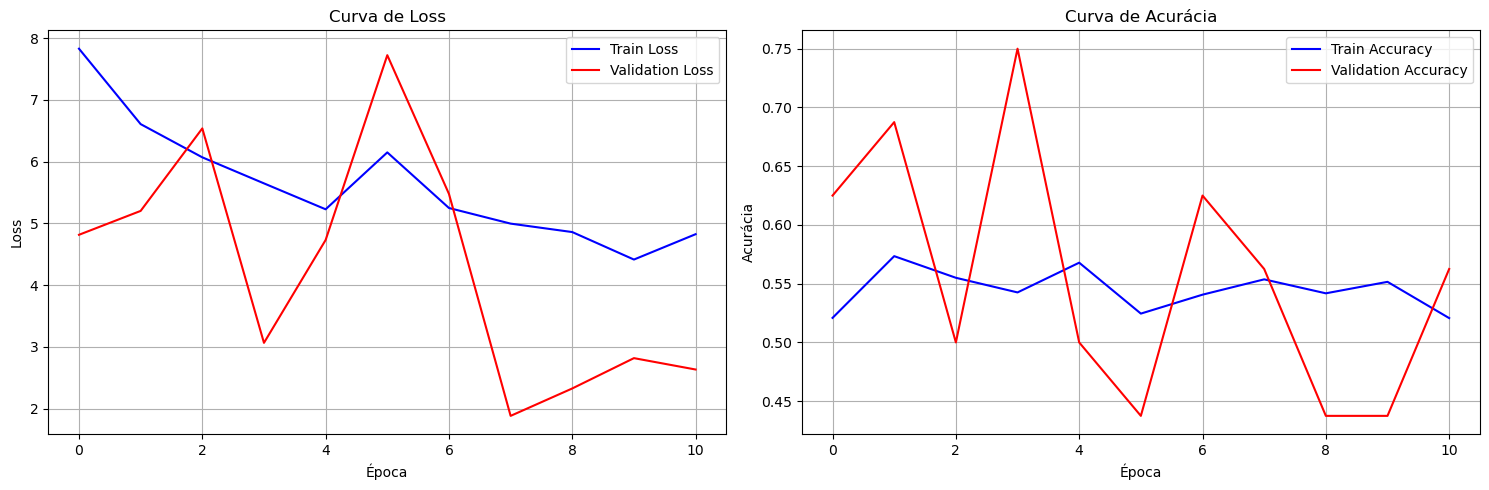

Carregando melhor modelo para avaliação final...

=== AVALIAÇÃO NO CONJUNTO DE TESTE ===
=== RELATÓRIO DE CLASSIFICAÇÃO ===
                     precision    recall  f1-score   support

             NORMAL     0.8655    0.8803    0.8729       234
    PNEUMONIA_VIRAL     0.7833    0.6351    0.7015       148
PNEUMONIA_BACTERIAL     0.8233    0.9050    0.8622       242

           accuracy                         0.8317       624
          macro avg     0.8241    0.8068    0.8122       624
       weighted avg     0.8297    0.8317    0.8281       624



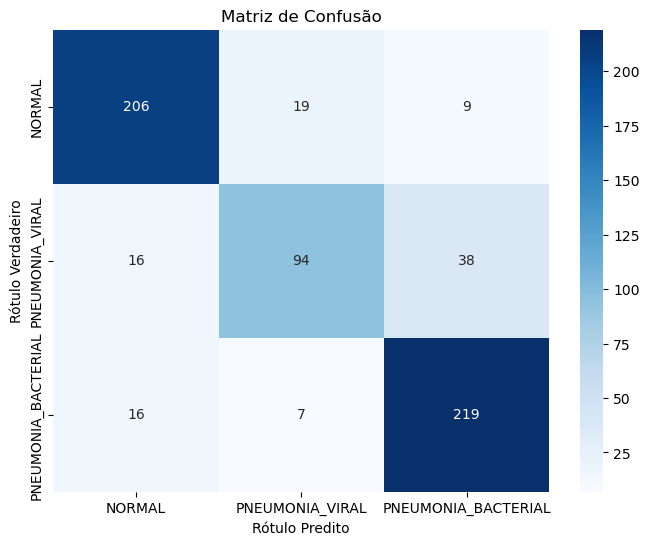

AUC NORMAL: 0.9670
AUC PNEUMONIA_VIRAL: 0.9097
AUC PNEUMONIA_BACTERIAL: 0.9425
AUC Médio: 0.9397

Treinamento e avaliação concluídos com sucesso!
Melhor acurácia de validação: 0.7500

=== ESTATÍSTICAS DO DATASET ===
Treinamento: 5216 amostras
Validação: 16 amostras
Teste: 624 amostras


In [1]:
# CNN Avançada para Classificação de Pneumonia (Normal, Viral, Bacteriana)
# Implementação baseada nas melhores práticas mencionadas no documento de referência

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd
from collections import Counter
import cv2
from torchvision import models
import torch.nn.functional as F

# Configuração de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

class ChestXRayDataset(Dataset):
    """Dataset personalizado com pré-processamento avançado e balanceamento"""
    
    def __init__(self, root_dir, transform=None, lung_segmentation=False):
        self.samples = []
        self.transform = transform
        self.root_dir = root_dir
        self.lung_segmentation = lung_segmentation
        self.class_names = ['NORMAL', 'PNEUMONIA_VIRAL', 'PNEUMONIA_BACTERIAL']
        
        # Mapeamento de labels
        label_mapping = {
            'NORMAL': 0,
            'PNEUMONIA_VIRAL': 1, 
            'PNEUMONIA_BACTERIAL': 2
        }
        
        for label_name in os.listdir(root_dir):
            label_dir = os.path.join(root_dir, label_name)
            if not os.path.isdir(label_dir):
                continue
                
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)
                
                # Classificação baseada no nome do arquivo
                if "NORMAL" in label_name.upper():
                    label = 0
                elif "PNEUMONIA" in label_name.upper():
                    # Classificação mais refinada baseada no nome do arquivo
                    if any(keyword in img_name.lower() for keyword in ['bacteria', 'bacterial']):
                        label = 2
                    elif any(keyword in img_name.lower() for keyword in ['virus', 'viral']):
                        label = 1
                    else:
                        # Se não conseguir identificar, pula a imagem
                        continue
                else:
                    continue
                    
                self.samples.append((img_path, label))
        
        print(f"Dataset carregado: {len(self.samples)} amostras")
        self._print_class_distribution()
    
    def _print_class_distribution(self):
        """Imprime a distribuição das classes"""
        labels = [sample[1] for sample in self.samples]
        class_counts = Counter(labels)
        print("Distribuição das classes:")
        for class_idx, count in class_counts.items():
            print(f"  {self.class_names[class_idx]}: {count} amostras")
    
    def get_class_weights(self):
        """Calcula pesos das classes para balanceamento"""
        labels = [sample[1] for sample in self.samples]
        class_counts = Counter(labels)
        total_samples = len(self.samples)
        
        # Pesos inversamente proporcionais à frequência
        weights = []
        for i in range(len(self.class_names)):
            if i in class_counts:
                weight = total_samples / (len(self.class_names) * class_counts[i])
                weights.append(weight)
            else:
                weights.append(0.0)
        
        return torch.FloatTensor(weights)
    
    def segment_lungs(self, image):
        """Segmentação pulmonar simples usando processamento de imagem"""
        # Convert PIL to numpy array
        img_array = np.array(image)
        
        # Se for RGB, converter para grayscale
        if len(img_array.shape) == 3:
            gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_array
        
        # Aplicar filtro Gaussiano para suavizar
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Threshold adaptativo
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 11, 2)
        
        # Encontrar contornos
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Criar máscara dos pulmões (contornos maiores)
        mask = np.zeros_like(gray)
        if contours:
            # Pegar os dois maiores contornos (assumindo que são os pulmões)
            contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
            cv2.fillPoly(mask, contours, 255)
        
        # Aplicar máscara na imagem original
        if len(img_array.shape) == 3:
            masked = cv2.bitwise_and(img_array, img_array, mask=mask)
        else:
            masked = cv2.bitwise_and(gray, gray, mask=mask)
        
        return Image.fromarray(masked)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        try:
            image = Image.open(img_path).convert("RGB")
            
            # Aplicar segmentação pulmonar se habilitada
            if self.lung_segmentation:
                image = self.segment_lungs(image)
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
        except Exception as e:
            print(f"Erro ao carregar imagem {img_path}: {e}")
            # Retornar uma imagem preta em caso de erro
            dummy_image = torch.zeros(3, 224, 224)
            return dummy_image, label

# Transformações avançadas com Data Augmentation
def get_transforms(phase='train'):
    """Define transformações específicas para cada fase"""
    
    if phase == 'train':
        # Data Augmentation para treinamento
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])  # ImageNet normalization
        ])
    else:
        # Transformações para validação/teste
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])

class AdvancedCNN(nn.Module):
    """CNN avançada com Transfer Learning usando ResNet50"""
    
    def __init__(self, num_classes=3, pretrained=True, dropout_rate=0.5):
        super(AdvancedCNN, self).__init__()
        
        # Backbone pré-treinado (ResNet50)
        self.backbone = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        
        # Substituir a última camada
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  # Remove a FC original
        
        # Classificador customizado
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Inicialização das camadas customizadas
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Inicialização personalizada dos pesos"""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

class ModelTrainer:
    """Classe para gerenciar o treinamento do modelo"""
    
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, 
                 scheduler=None, device='cpu'):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        
        # Histórico de treinamento
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []
        
    def train_epoch(self):
        """Treina por uma época"""
        self.model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        
        for batch_idx, (images, labels) in enumerate(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            
            # Forward pass
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Estatísticas
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            
            # Log do progresso
            if batch_idx % 50 == 0:
                print(f'Batch {batch_idx}/{len(self.train_loader)}, '
                      f'Loss: {loss.item():.4f}')
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = correct_predictions / total_samples
        
        return epoch_loss, epoch_acc
    
    def validate_epoch(self):
        """Valida por uma época"""
        self.model.eval()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        
        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_predictions += (predicted == labels).sum().item()
                total_samples += labels.size(0)
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = correct_predictions / total_samples
        
        return epoch_loss, epoch_acc
    
    def train(self, num_epochs, early_stopping_patience=10):
        """Treinamento completo com early stopping"""
        best_val_acc = 0.0
        patience_counter = 0
        
        print(f"Iniciando treinamento por {num_epochs} épocas...")
        print("-" * 60)
        
        for epoch in range(num_epochs):
            print(f'Época {epoch+1}/{num_epochs}')
            
            # Treinamento
            train_loss, train_acc = self.train_epoch()
            
            # Validação
            val_loss, val_acc = self.validate_epoch()
            
            # Atualizar scheduler
            if self.scheduler:
                old_lr = self.optimizer.param_groups[0]['lr']
                self.scheduler.step(val_loss)
                new_lr = self.optimizer.param_groups[0]['lr']
                if new_lr != old_lr:
                    print(f'Learning rate reduzido de {old_lr:.6f} para {new_lr:.6f}')
            
            # Salvar histórico
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)
            
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
            
            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # Salvar melhor modelo
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss
                }, 'best_model.pth')
                print(f'Novo melhor modelo salvo! Val Acc: {val_acc:.4f}')
            else:
                patience_counter += 1
            
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping após {early_stopping_patience} épocas sem melhoria')
                break
            
            print("-" * 60)
        
        print(f'Treinamento concluído! Melhor Val Acc: {best_val_acc:.4f}')
        return best_val_acc
    
    def plot_training_history(self):
        """Plota o histórico de treinamento"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(self.train_losses, label='Train Loss', color='blue')
        ax1.plot(self.val_losses, label='Validation Loss', color='red')
        ax1.set_title('Curva de Loss')
        ax1.set_xlabel('Época')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # Accuracy
        ax2.plot(self.train_accuracies, label='Train Accuracy', color='blue')
        ax2.plot(self.val_accuracies, label='Validation Accuracy', color='red')
        ax2.set_title('Curva de Acurácia')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('Acurácia')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

def evaluate_model(model, test_loader, device, class_names):
    """Avaliação completa do modelo"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Métricas
    print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
    print(classification_report(all_labels, all_predictions, 
                              target_names=class_names, digits=4))
    
    # Matriz de confusão
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calcular AUC para classificação multiclasse (One-vs-Rest)
    all_probabilities = np.array(all_probabilities)
    try:
        auc_scores = {}
        for i, class_name in enumerate(class_names):
            # Binarizar labels para classe i vs resto
            binary_labels = (np.array(all_labels) == i).astype(int)
            auc = roc_auc_score(binary_labels, all_probabilities[:, i])
            auc_scores[class_name] = auc
            print(f"AUC {class_name}: {auc:.4f}")
        
        mean_auc = np.mean(list(auc_scores.values()))
        print(f"AUC Médio: {mean_auc:.4f}")
    except Exception as e:
        print(f"Erro ao calcular AUC: {e}")
    
    return all_predictions, all_labels, all_probabilities

def main():
    """Função principal"""
    
    # Configurações otimizadas baseadas no seu dataset
    DATA_DIR = '/caminho/para/chest_xray'  # Modifique para seu dataset
    BATCH_SIZE = 16  # Reduzido devido ao dataset de validação pequeno
    NUM_EPOCHS = 30  # Reduzido devido ao dataset pequeno
    LEARNING_RATE = 0.0001  # Menor LR para fine-tuning
    WEIGHT_DECAY = 1e-4
    
    print("=== CNN AVANÇADA PARA CLASSIFICAÇÃO DE PNEUMONIA ===")
    print("Baseada em Transfer Learning com ResNet50")
    print("=" * 60)
    
    # Verificar se o diretório existe
    if not os.path.exists(DATA_DIR):
        print(f"ATENÇÃO: Usando dataset atual detectado automaticamente...")
        # Tentar encontrar automaticamente os diretórios
        current_dir = os.getcwd()
        possible_dirs = ['chest_xray', 'dataset', 'data']
        
        DATA_DIR = None
        for possible_dir in possible_dirs:
            if os.path.exists(possible_dir):
                DATA_DIR = possible_dir
                break
        
        if DATA_DIR is None:
            print("ERRO: Não foi possível localizar o dataset!")
            print("Por favor, ajuste o caminho DATA_DIR no código.")
            return
        else:
            print(f"Dataset encontrado em: {DATA_DIR}")
    
    try:
        # Carregar datasets
        print("Carregando datasets...")
        train_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'train'), 
            transform=get_transforms('train'),
            lung_segmentation=False  # Ativar se desejar segmentação
        )
        
        val_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'val'), 
            transform=get_transforms('val')
        )
        
        test_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'test'), 
            transform=get_transforms('test')
        )
        
        # Verificar se o dataset de validação é muito pequeno
        if len(val_dataset) < 32:
            print(f"⚠️  ATENÇÃO: Dataset de validação muito pequeno ({len(val_dataset)} amostras)")
            print("Isso pode afetar a estabilidade do treinamento.")
            print("Considerando reduzir batch_size e ajustar early_stopping...")
            BATCH_SIZE = min(BATCH_SIZE, len(val_dataset) // 2)
            
        # Calcular pesos das classes para balanceamento
        class_weights = train_dataset.get_class_weights().to(device)
        print(f"Pesos das classes: {class_weights}")
        
        # DataLoaders com configurações otimizadas
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                                shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=min(BATCH_SIZE, len(val_dataset)), 
                              shuffle=False, num_workers=2, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                               shuffle=False, num_workers=2, pin_memory=True)
        
        # Modelo
        print("Inicializando modelo...")
        model = AdvancedCNN(num_classes=3, pretrained=True, dropout_rate=0.3)
        model = model.to(device)
        
        # Critério com pesos das classes
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        # Otimizador com configurações mais conservadoras
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, 
                              weight_decay=WEIGHT_DECAY)
        
        # Scheduler
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
        
        # Treinador
        trainer = ModelTrainer(model, train_loader, val_loader, criterion, 
                             optimizer, scheduler, device)
        
        # Treinamento com patience ajustado para dataset pequeno
        early_stopping_patience = 7 if len(val_dataset) < 50 else 10
        best_val_acc = trainer.train(NUM_EPOCHS, early_stopping_patience=early_stopping_patience)
        
        # Plotar histórico
        trainer.plot_training_history()
        
        # Carregar melhor modelo para avaliação
        if os.path.exists('best_model.pth'):
            print("Carregando melhor modelo para avaliação final...")
            checkpoint = torch.load('best_model.pth', map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
        
        # Avaliação final
        print("\n=== AVALIAÇÃO NO CONJUNTO DE TESTE ===")
        class_names = ['NORMAL', 'PNEUMONIA_VIRAL', 'PNEUMONIA_BACTERIAL']
        predictions, labels, probabilities = evaluate_model(
            model, test_loader, device, class_names
        )
        
        print("\nTreinamento e avaliação concluídos com sucesso!")
        print(f"Melhor acurácia de validação: {best_val_acc:.4f}")
        
        # Estatísticas do dataset
        print(f"\n=== ESTATÍSTICAS DO DATASET ===")
        print(f"Treinamento: {len(train_dataset)} amostras")
        print(f"Validação: {len(val_dataset)} amostras")
        print(f"Teste: {len(test_dataset)} amostras")
        
    except Exception as e:
        print(f"Erro durante a execução: {e}")
        import traceback
        traceback.print_exc()
        print("\nVerifique se o dataset está organizado corretamente:")
        print("dataset/")
        print("├── train/")
        print("│   ├── NORMAL/")
        print("│   └── PNEUMONIA/")
        print("├── val/")
        print("│   ├── NORMAL/")
        print("│   └── PNEUMONIA/")
        print("└── test/")
        print("    ├── NORMAL/")
        print("    └── PNEUMONIA/")

if __name__ == "__main__":
    main()